# Pricing Bonus Certificates on Deutsche Telekom

In the following notebook, we investigate Bonus Certificates linked to the Telekom stock. A Bonus Certificate is a type of structured derivative that offers investors conditional protection against moderate price declines, while still allowing participation in positive performance. We assume that any fraction of the security is tradable and that the risk-free interest rate $r$ is constant at 2% per annum. Our analysis focuses on understanding the product’s payoff structure, modeling its fair price under the Black-Scholes framework, and confirming the analytical price through a Monte Carlo simulation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew

sys.path.insert(0, str(Path.cwd().parent / "src"))
from bonus_certificate import (
    bonus_certificate_mc, bonus_certificate_payoff, bonus_certificate_price, bs_put,
    barrier_survival_probability, fit_gbm, load_prices, log_returns, simulate_gbm_paths,
)

r = 0.02                         # risk-free rate, per annum
rng = np.random.default_rng(42)  # fixed seed for reproducibility

## 1. Data

We begin by loading the historical closing prices of Telekom stock from the dataset `Telekom.csv`. The data spans **10 years**, from **June 17, 2014** to **June 16, 2024**. After parsing the dates and setting them as the index, we visualize the stock price evolution over time.

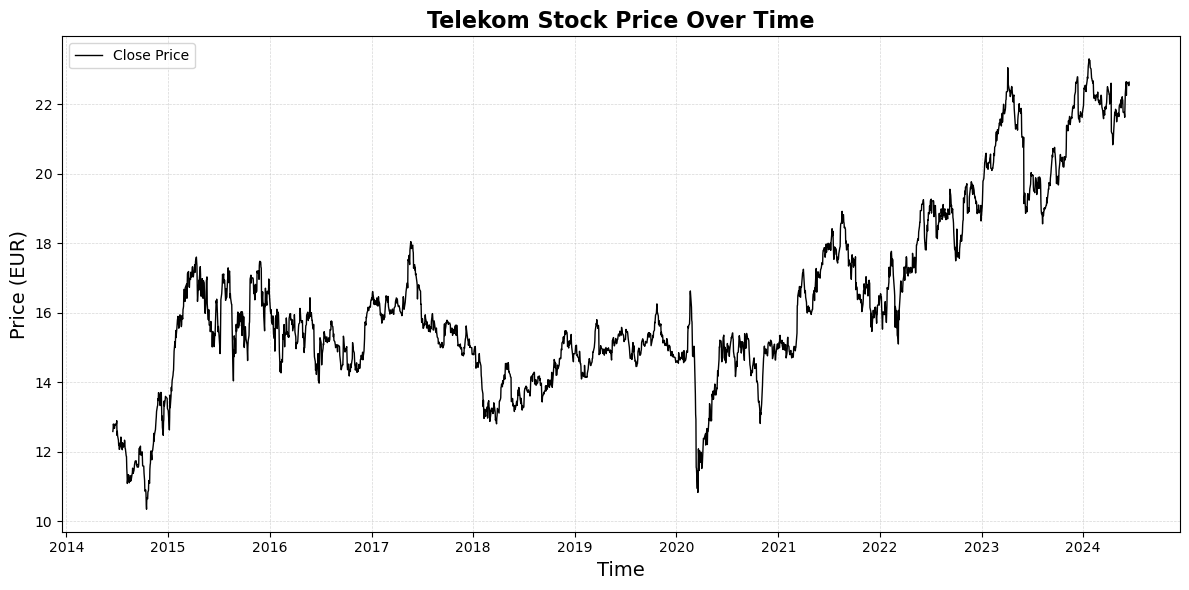

In [2]:
df = load_prices().to_frame("Close")

plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='black', linewidth=1, label='Close Price')
plt.title('Telekom Stock Price Over Time', fontsize=16, weight='bold')
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price (EUR)', fontsize=14)
plt.grid(True, linestyle='--', linewidth=.5, alpha=.5)
plt.legend()
plt.tight_layout()
plt.show()

Next, we compute the **log-returns** of the Telekom stock based on the daily closing prices. The log-return at time step $i$ is defined as
$$Y_i = \log\left(\frac{P_i}{P_{i-1}}\right).$$

Log-returns are widely used in financial modeling because of their desirable properties — notably, time additivity, and the fact that they tend to be approximately normally distributed over short intervals.

Again, we visualize their evolution over the full 10-year period to gain some insight into the volatility and the dynamic of the asset.

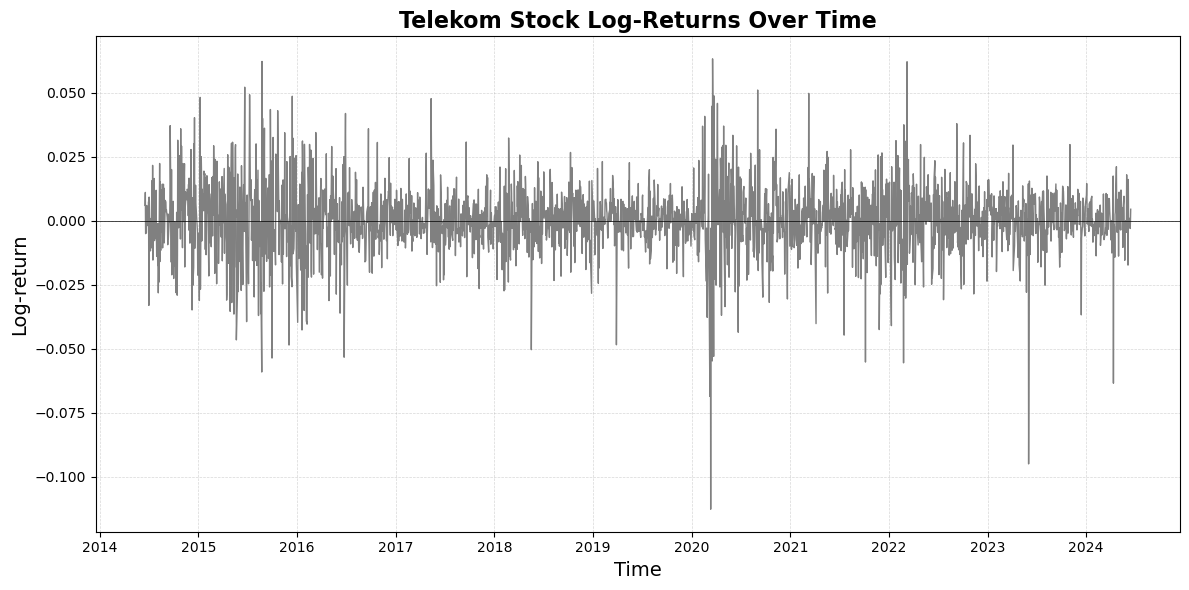

In [3]:
log_rets = log_returns(df['Close'])

plt.figure(figsize=(12, 6))
plt.plot(log_rets, color='grey', linewidth=1)
plt.title('Telekom Stock Log-Returns Over Time', fontsize=16, weight='bold')
plt.xlabel('Time', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylabel('Log-return', fontsize=14)
plt.grid(True, linestyle='--', linewidth=.5, alpha=.5)
plt.tight_layout()
plt.show()

To capture the key statistical features of the log returns, we report standard summary metrics such as the mean, standard deviation, minimum, maximum, and selected quantiles.

In [4]:
summary_stats = pd.DataFrame({
    "Statistic": ["Mean", "Variance", "Standard Deviation", "Minimum", "Maximum",
                  "First Quartile (Q1)", "Median (Q2)", "Third Quartile (Q3)"],
    "Value": [log_rets.mean(), log_rets.var(), log_rets.std(), log_rets.min(), log_rets.max(),
              log_rets.quantile(0.25), log_rets.quantile(0.50), log_rets.quantile(0.75)],
})
summary_stats

,Statistic,Value
0,Mean,0.000231
1,Variance,0.000179
2,Standard Deviation,0.013379
3,Minimum,-0.112673
4,Maximum,0.063141
5,First Quartile (Q1),-0.005909
6,Median (Q2),0.000000
7,Third Quartile (Q3),0.007092


## 2. Calibrating the Black–Scholes model

In this section, we aim to fit the classical Black-Scholes model to the historical price data of the Telekom stock. This involves estimating the model's core parameters, namely the drift and volatility by using the empirical log-returns derived from the time series. We assume that prices follow a **geometric Brownian motion**, given by the stochastic differential equation:

$$
dB_t = rB_{t}dt \\
dP_t = \mu P_t \, dt + \sigma P_t \, dW_t
$$

where $B_t$ and $P_t$ are the risk free bank account and the stock price at time $t$, $\mu$ is the drift (constant), $\sigma$ is the volatility (constant) and $W_t$ is a standard Brownian motion. Let $Y_i$ denote the $i$‑th log‐return and $\widehat{Y}$ its sample mean.  By Itô’s lemma, the log‐price under the Black–Scholes model satisfies the SDE  
$$
d\ln P_t = \Bigl(\mu - \tfrac12\sigma^2\Bigr)\,dt + \sigma\,dW_t.
$$  
Discretizing over a time step $\Delta$ = $t_{i+1} - t_{i}$ gives i.i.d. log‐returns  
$$
Y_{i+1}
= \ln P_{t_{i+1}} - \ln P_{t_i}
\;\sim\;\mathcal{N}\!\bigl((\mu - \tfrac12\sigma^2)\,\Delta,\;\sigma^2\,\Delta\bigr).
$$  
Choosing a daily time‐step $\Delta = \tfrac1{252}$ (assuming 252 trading days per year), we obtain the estimators  
$$
\hat\sigma 
= \sqrt{\frac{\widehat{\mathrm{Var}}(Y)}{\Delta}},
\qquad
\hat\mu 
= \frac{\widehat{Y}}{\Delta} + \tfrac12\,\hat\sigma^2,
$$  
both of which carry annual units thanks to our choice of $\Delta$. In order to simulate the price path, we define the per‐step parameters as
$$
\mu_{\Delta}  = (\hat\mu - \tfrac12\,\hat\sigma^2)\,\Delta,
\qquad
\sigma_{\Delta} = \hat\sigma\,\sqrt{\Delta},
$$  
and simulate each daily increment via  
$$
\Delta\ln P = \mu_{\Delta} + \sigma_{\Delta}\,Z,
\quad Z\sim\mathcal{N}(0,1),
$$  
which yields the familiar discrete‐time update  
$$
P_{t+\Delta}
= P_t \exp\bigl(\mu_{\Delta} + \sigma_{\Delta}\,Z\bigr).
$$  

This exact discrete‐time scheme is fully consistent with the continuous‐time Black–Scholes SDE.  In a Monte Carlo setting, we generate $M$ independent paths of length $T/\Delta=252$, each reflecting one possible stock evolution.  As $M\to\infty$, the diffusion noise averages out and the sample mean path converges to the deterministic drift trend driven by $\hat\mu$.

The following plots illustrate the effect of increasing $M$ on the simulated average price paths, using $P_0$ = 12.59€, demonstrating convergence toward the expected price trajectory as the sample size grows.

sigma = 21.24% per year, mu = 8.08% per year


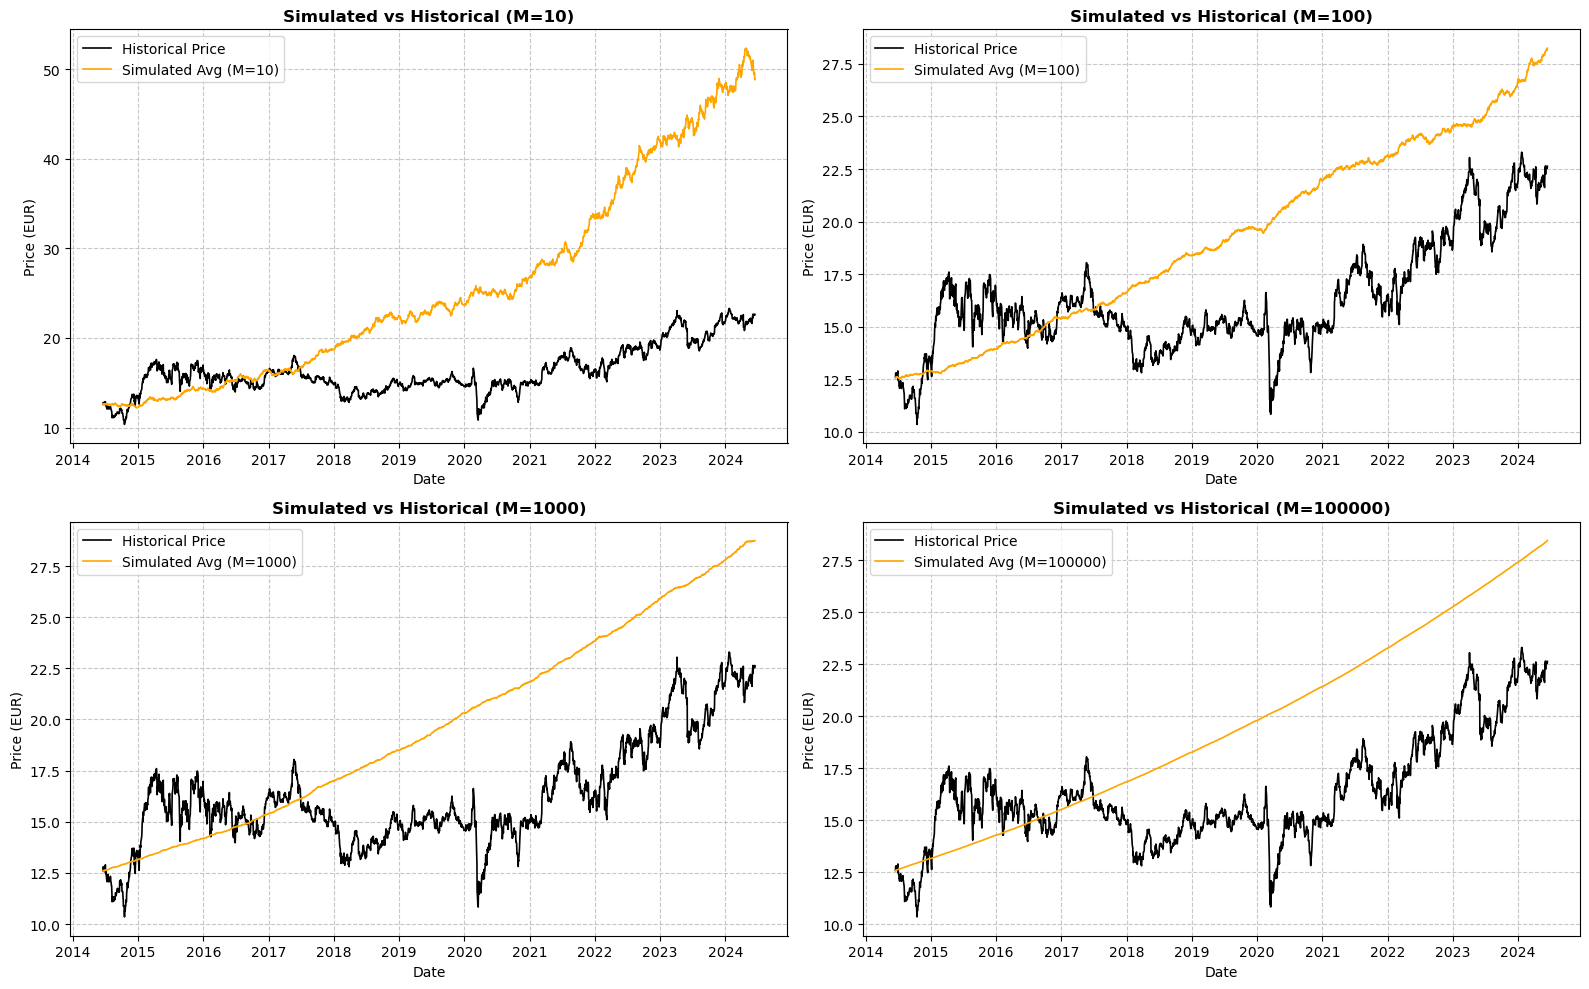

In [5]:
params = fit_gbm(df['Close'])          # annualized estimates, Delta = 1/252
sigma_annual, drift_annual = params.sigma, params.mu
print(f"sigma = {sigma_annual:.2%} per year, mu = {drift_annual:.2%} per year")

P0 = df['Close'].iloc[0]               # historical initial price
N = len(log_rets)                      # number of trading days in the sample

M_values = [10, 100, 1000, 100000]
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, M in enumerate(M_values):
    price_paths = simulate_gbm_paths(P0, drift_annual, sigma_annual, T=N / 252, n_steps=N, n_paths=M, rng=rng)
    average_path = price_paths.mean(axis=0)

    axs[i].plot(df.index, df['Close'], color='black', linewidth=1.2, label='Historical Price')
    axs[i].plot(df.index, average_path, color='orange', linewidth=1.2, label=f'Simulated Avg (M={M})')
    axs[i].set_title(f'Simulated vs Historical (M={M})', fontsize=12, fontweight='bold')
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Price (EUR)')
    axs[i].grid(True, linestyle='--', alpha=0.7)
    axs[i].legend()

plt.tight_layout()
plt.show()

By averaging over all simulated paths, the randomness contributed by the diffusion term smoothes out, allowing the underlying drift component of the Black-Scholes model to become clearly visible. This demonstrates how the expected trend drives the price evolution when stochastic fluctuations are averaged out.

## 3. The product: Bonus Certificates

Bonus Certificates are structured financial products that provide investors with the opportunity for enhanced returns compared to directly holding the underlying asset, usually a stock. These products blend characteristics of traditional investments and options, offering a minimum guaranteed payout (the bonus level) as long as the underlying asset’s price does not fall below a predefined barrier level during the certificate’s lifetime.

In the following, we consider the payoff profile of a Bonus Certificate as an illustrative example. We assume a barrier level $H = 15$ and a bonus level $B=25$. The underlying asset price at maturity $P_T$ is varied between 0 and 40 to visualize the corresponding payoff of the certificate. This visualization highlights how the payoff behaves when the barrier is not breached during the lifetime of the derivative and shows the position of the terminal price relative to the bonus level.

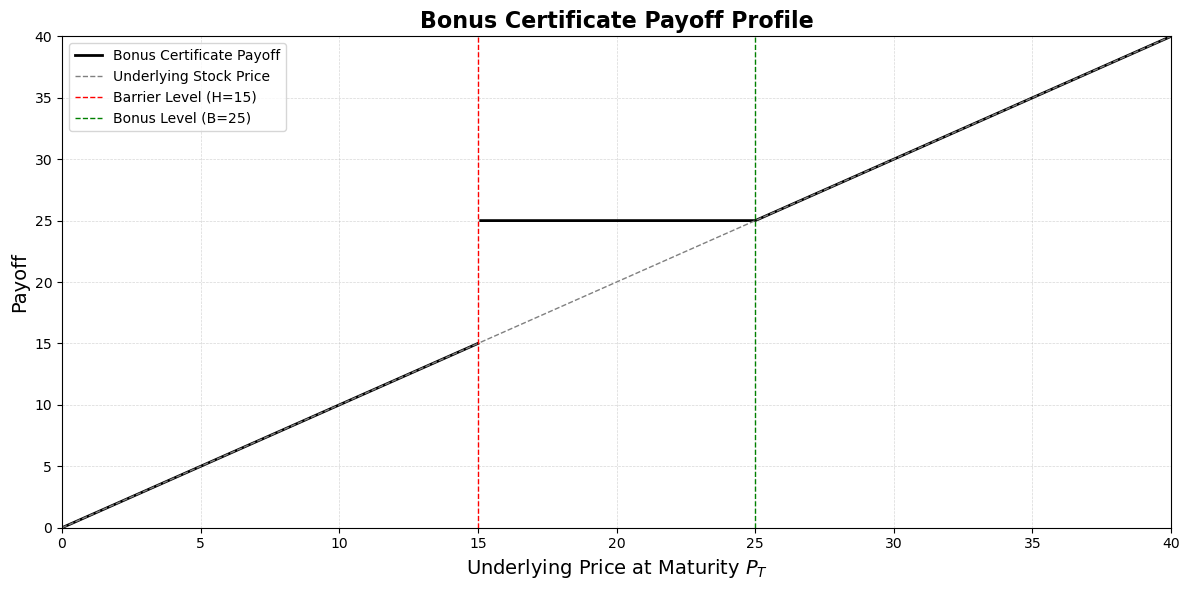

In [6]:
H = 15 # Barrier
B = 25 # Bonus level

PT1 = np.linspace(0, 15, 500)
PT2 = np.linspace(15.1, 40, 500)

payoff1 = np.where(PT1 <= H, PT1, np.where(PT1 <= B, B, PT1))
payoff2 = np.where(PT2 <= H, PT2, np.where(PT2 <= B, B, PT2))

plt.figure(figsize=(12, 6))

plt.plot(PT1, payoff1, label='Bonus Certificate Payoff', color='black', linewidth=2)
plt.plot(PT2, payoff2, color='black', linewidth=2)
plt.plot(PT1, PT1, label='Underlying Stock Price', color='gray', linestyle='--', linewidth=1)
plt.plot(PT2, PT2, color='gray', linestyle='--', linewidth=1)

plt.axvline(H, color='red', linestyle='--', linewidth=1, label=f'Barrier Level (H={H})')
plt.axvline(B, color='green', linestyle='--', linewidth=1, label=f'Bonus Level (B={B})')
plt.title('Bonus Certificate Payoff Profile', fontsize=16, weight = 'bold')
plt.xlabel('Underlying Price at Maturity $P_T$', fontsize=14)
plt.ylabel('Payoff', fontsize=14)
plt.xlim(0, 40)
plt.ylim(0, 40)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', linewidth=.5, alpha=.5)
plt.tight_layout()
plt.show()

Investors may be drawn to Bonus Certificates because they offer the potential for higher returns compared to directly holding the underlying asset - especially when the stock price stays between the barrier and the bonus level. These instruments provide conditional downside protection: As long as the barrier is not breached, the investor is protected against moderate losses. In addition, if the underlying remains above the barrier at maturity, the investor receives a fixed bonus payout, which can exceed the return from simply holding the asset. This structure combines elements of capital preservation with the opportunity for enhanced yield in sideways or moderately bullish markets.

However, the main risk lies in the (possible) high volatility of the underlying asset’s price. Due to significant price fluctuations, there is an increased probability that the price will fall below the safety threshold at some point during the term. If the barrier is breached, the bonus mechanism expires, and the investor loses the protection, facing the full downside risk of the underlying.

This barrier risk is a key concern, as it can significantly affect the certificate’s payoff. Additionally, because Bonus Certificates are structured and more complex financial products, there are potential liquidity risks - it may be harder to sell them quickly or at a fair price compared to more straightforward investments.

In summary, while Bonus Certificates can be appealing for enhanced returns with partial protection, investors must carefully consider the volatility-driven barrier risk and the complexities that might affect liquidity.

## 4. Replication

As stated before, the payoff of a Bonus Certificate depends on the price of the corresponding underlying at Maturity $T$ **and** on whether the barrier $H$ was breached at any time during its lifetime. More precisely, given a predetermined Bonus Level $B$, the payoff of the Bonus Certificate equals B if and only if the barrier $H$ was not touched or breached during the product's lifetime and the terminal price $P_T \leq B$. In all other cases the payoff will simply be the terminal price $P_T$ itsself. We can formalize this by expressing the payoff $D$ as
$$D = B \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:,\: P_T \leq B\:\}} + P_T \cdot \mathbf{1}_{{\{\:\min_{t \in [0,T]} P_t > H\:,\: P_T \leq B\:\}}^c},$$ 
which is equivalent to $$\begin{align*} D &= B \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:,\: P_T \leq B\:\}} + P_T - P_T \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:,\: P_T \leq B\:\}}\\
\Leftrightarrow D &= (B - P_T) \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:,\: P_T \leq B\:\}} + P_T \\
\Leftrightarrow D &= (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} + P_T
\end{align*}$$where $(B - P_T)^+ = \max\{B-P_T, 0 \}$. We can therefore replicate the payoff of the Bonus Certificate by a long on both, the Down-and-out put option with Strike $B$ and the underlying asset $P_t$.

## 5. Closed-form price

Our objective is now to find a fair value for the Bonus Certificate. Because the market model is complete, the price of any contingent claim coincides with the price of its replicating portfolio. We will use this fact along with risk-neutral pricing to price the Bonus Certificate.
$$
\begin{align*} V_0^D &= \mathbb{E}_{\mathbb{\tilde{Q}}}\left[e^{-r  T} D \right] = \mathbb{E}_{\mathbb{\tilde{Q}}}\left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} + e^{-rT}P_T\right]\\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-rT} P_T \right]\\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (B - P_T)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0.
\end{align*}$$
Now, since $$ (B-P_T)^+ = (P_T - B)^+ - (P_T - B)$$ we further obtain that
$$
\begin{align*} V_0^D &= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} \left((P_T - B)^+ - (P_T - B)\right) \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0 \\
&= \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (P_T - B)^+ \cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] - \mathbb{E}_{\mathbb{\tilde{Q}}} \left[e^{-r \cdot T} (P_T - B)\cdot \mathbf{1}_{\{\:\min_{t \in [0,T]} P_t > H\:\}} \right] + P_0\\
&= DOC(P_0,0) + e^{-rT} B Q^{(2)} - P_0(Q^{(1)}-1) \\
&= C(P_0,0) - KOD(P_0,0) + e^{-rT} B Q^{(2)} - P_0(Q^{(1)}-1),
\end{align*}$$
where $C(P_0,0)$ denotes the vanilla call option price at $t=0$, $KOD(P_0,0)$ the knockout discount, by which the knockout barrier $H$ lowers the price and $Q^{(1)}$, $Q^{(2)}$ the probabilities that the barrier is never hit under the share measure and under the risk-neutral measure $\tilde{\mathbb{Q}}$. For a GBM with log-drift $\nu$,
$$\mathbb{P}\Big(\min_{t \le T} P_t > H\Big) = \Phi\left(\frac{\ln(P_0/H) + \nu T}{\sigma\sqrt{T}}\right) - \left(\frac{H}{P_0}\right)^{2\nu/\sigma^2} \Phi\left(\frac{-\ln(P_0/H) + \nu T}{\sigma\sqrt{T}}\right),$$
with $\nu = r + \tfrac12\sigma^2$ for $Q^{(1)}$ and $\nu = r - \tfrac12\sigma^2$ for $Q^{(2)}$. The down-and-out call uses the standard closed form.

We now explicitely compute the price of a Bonus Certificate on the Telekom stock with $P_0$ equal to the price quoted on 14.06.2024, barrier level 16, bonus level 24 and maturity of 1 year. We will use the market parameters from above and since we are valuating with respect to the risk-neutral measure, we will use the risk-free rate $r$ as drift.

In [7]:
P0 = df.at[pd.Timestamp('2024-06-14'), 'Close']
H = 16   # barrier
B = 24   # bonus level
T = 1    # maturity in years

The formulas are implemented in [`src/bonus_certificate/pricing.py`](../src/bonus_certificate/pricing.py). Besides the price, we also report its two building blocks: the share itself and the down-and-out put.

In [8]:
analytical_price = bonus_certificate_price(P0, B, H, r, sigma_annual, T)
q2 = barrier_survival_probability(P0, H, r, sigma_annual, T)

print(f"Share price P0                        : {P0:8.4f}")
print(f"Down-and-out put (B={B}, H={H})        : {analytical_price - P0:8.4f}")
print(f"  for comparison, vanilla put (K={B})  : {bs_put(P0, B, r, sigma_annual, T):8.4f}")
print(f"Bonus Certificate                     : {analytical_price:8.4f}")
print(f"Risk-neutral P(barrier never hit)     : {q2:8.2%}")

Share price P0                        :  22.6300
Down-and-out put (B=24, H=16)        :   1.6210
  for comparison, vanilla put (K=24)  :   2.4314
Bonus Certificate                     :  24.2510
Risk-neutral P(barrier never hit)     :   89.54%


## 6. Monte Carlo validation

To confirm the pricing formula derived analytically in Task 5, we use a Monte Carlo simulation approach. The idea is to simulate multiple price paths of the underlying asset under the risk-neutral measure and evaluate the expected discounted payoff of the Bonus Certificate. This time we simulate **future** price paths under the risk-neutral measure, i.e. with the risk-free rate $r = 2\%$ as drift.

We simulate 200,000 price paths of the underlying asset over a one-year horizon using the geometric Brownian motion model. At each timestep, we monitor whether the barrier $H$ has been breached.

To achieve computational efficiency, we employ vectorized NumPy operations to:

1. Simulate all Brownian increments simultaneously.

2. Track barrier breaches for each path.

3. Calculate final *discounted* payoffs accordingly.

Additionally, we use antithetic variables to reduce the variance of our Monte Carlo estimator, improving the accuracy and convergence speed of the price estimate without increasing the number of simulations.

The price of the Bonus Certificate is then estimated as the average discounted payoff across all simulated paths. This approach allows us to approximate the fair value of the product under the risk-neutral measure efficiently and with high numerical stability.

In [9]:
monte_carlo_price, mc_se = bonus_certificate_mc(P0, B, H, r, sigma_annual, T, n_steps=1000, n_paths=200_000,
                                       rng=rng, antithetic=True, bridge=False)
print(f"Monte Carlo price: {monte_carlo_price:.4f} ± {1.96 * mc_se:.4f} (95% CI)")

Monte Carlo price: 24.2733 ± 0.0062 (95% CI)


To validate the analytical pricing formula, we compared it to the result obtained via Monte Carlo simulation. The absolute error and relative error between the two methods were calculated as follows:

In [10]:
def compare_prices(true_value, estimated_value, label="Price"):
    abs_error = abs(true_value - estimated_value)
    rel_error = abs_error / abs(true_value) * 100 if true_value != 0 else float('inf')
    
    print(f"{label}:")
    print(f"  Analytical value  = {true_value:.6f}")
    print(f"  Monte Carlo value = {estimated_value:.6f}")
    print(f"  Absolute error    = {abs_error:.6f}")
    print(f"  Relative error    = {rel_error:.4f}%\n")

compare_prices(analytical_price, monte_carlo_price, label="Comparison of results")

Comparison of results:
  Analytical value  = 24.250959
  Monte Carlo value = 24.273327
  Absolute error    = 0.022368
  Relative error    = 0.0922%



The small error observed confirms that the Monte Carlo method provides a close numerical approximation to the theoretical price. Such small deviations are normal due to the randomness of simulations. The result supports the correctness of the analytical pricing formula derived earlier. If higher accuracy is needed, the simulation can be refined by increasing the number of simulated paths or applying variance reduction techniques.

##### Overestimating Barrier Options with Monte Carlo Simulation:  

When Calculating the Monte Carlo price multiple times one might notice, that it is always slightly higher then the analytical price. One might suggest that the Absolute error between the analytical and numerical price might not only be caused by the randomness of the simulation. In fact the Monte Carlo price is always slightly overestimating the price of the bonus certificate, as it only checks if the barrier was breached in discrete time steps. In theory a price could breach the barrier between two time steps but not be detected by the Monte Carlo Payoff simulation algorithm, leading to more bonus-paying simulations and in this way driving up the price of the option. Therefore increasing the number of steps in the path simulation, would decrease the bias, but on the other hand grow the computational effort significantly.

### Removing the bias with a Brownian-bridge correction

The bias can be removed without refining the grid. Conditional on the simulated values $P_{t_i}$ and $P_{t_{i+1}}$ (both above $H$), the log-price in between is a Brownian bridge, and the probability that it dips below the barrier is known in closed form:
$$
\mathbb{P}\big(\text{barrier hit in } [t_i, t_{i+1}] \,\big|\, P_{t_i}, P_{t_{i+1}}\big) = \exp\left(-\frac{2 \ln(P_{t_i}/H)\,\ln(P_{t_{i+1}}/H)}{\sigma^2 \Delta t}\right).
$$
Instead of a 0/1 barrier indicator, each path is weighted by its probability of surviving all intervals. This makes the estimator unbiased for the continuously monitored barrier at any number of time steps.

In [11]:
steps = [4, 12, 52, 252, 1000]
rows = []
for n in steps:
    discrete, se_d = bonus_certificate_mc(P0, B, H, r, sigma_annual, T, n_steps=n, n_paths=200_000, rng=10, bridge=False)
    bridged, se_b = bonus_certificate_mc(P0, B, H, r, sigma_annual, T, n_steps=n, n_paths=200_000, rng=10, bridge=True)
    rows.append({"time steps": n, "discrete barrier": discrete, "Brownian bridge": bridged, "95% CI ±": 1.96 * se_b})
convergence = pd.DataFrame(rows).set_index("time steps")
convergence["closed form"] = analytical_price
convergence.round(4)

,discrete barrier,Brownian bridge,95% CI ±,closed form
time steps,,,,
4,24.5020,24.2445,0.0051,24.251
12,24.4225,24.2499,0.0056,24.251
52,24.3551,24.2599,0.0059,24.251
252,24.2979,24.2529,0.0061,24.251
1000,24.2790,24.2556,0.0061,24.251


Checking the barrier only on the grid overprices the certificate by up to €0.25, and the bias decays slowly as the grid gets finer. With the bridge correction, the Monte Carlo price matches the closed form within its confidence interval even with only 4 time steps.

## 7. Risk profile under the real-world measure

We now simulate the evolution of the underlying price and the payoff of the Bonus Certificate under the physical probability measure. This allows us to investigate the risk characteristics of the instrument and compare them directly with those of the underlying asset. Specifically, we compare the distributional properties of the terminal asset price $P_T$​ and the corresponding certificate payoff. For both variables, we compute key summary statistics: the mean, variance, skewness, kurtosis, and the 5% quantile (i.e., Value-at-Risk at 95% confidence level).

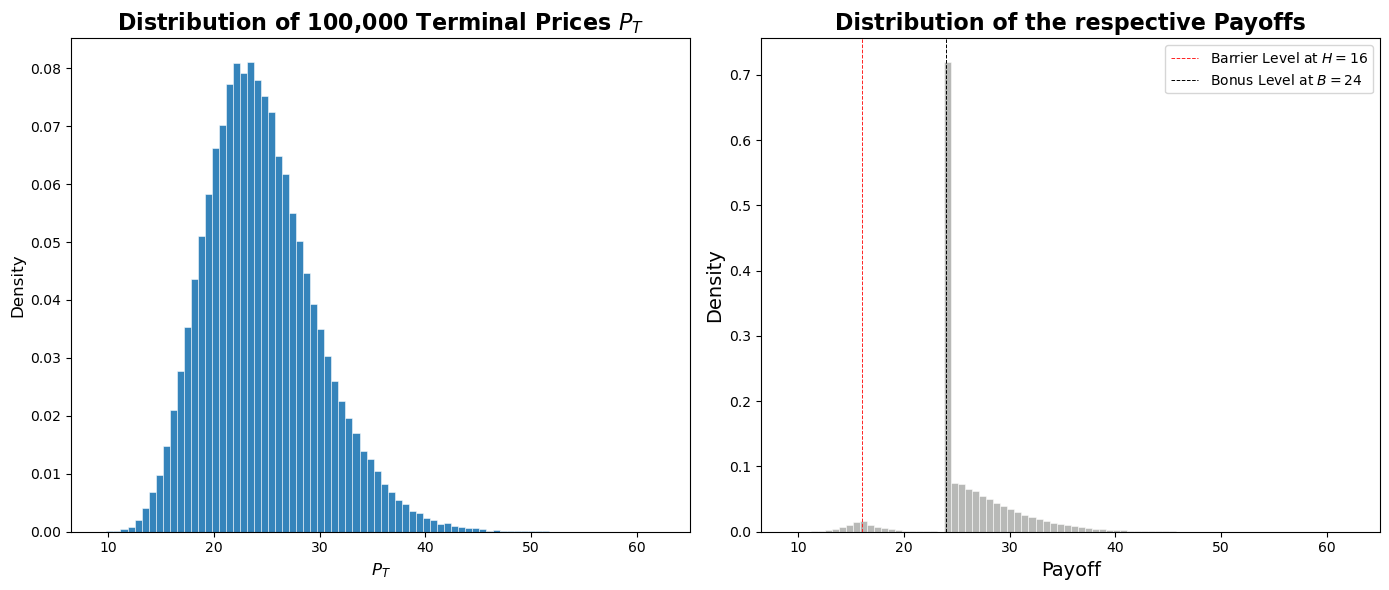

P(barrier hit) = 5.94%,  P(payoff = B) = 44.23%


,Terminal price,Certificate payoff
Mean,24.5217,25.8590
Variance,27.6628,18.7504
Standard Deviation,5.2595,4.3302
Skewness,0.6304,0.6524
Excess Kurtosis,0.6869,2.9851
Max,62.3515,62.3515
Min,9.1773,9.1773
5% Quantile (VaR),16.8825,17.9776


In [12]:
M = 100_000
P_paths = simulate_gbm_paths(P0, drift_annual, sigma_annual, T, n_steps=252, n_paths=M, rng=rng)
PT = P_paths[:, -1]
breached = (P_paths <= H).any(axis=1)
payoffs = np.where(breached, PT, PT + np.maximum(B - PT, 0))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(PT, bins=80, color='#1f77b4', alpha=0.9, density=True, edgecolor='white', linewidth=0.4)
plt.title(f'Distribution of {M:,} Terminal Prices $P_T$', fontsize=16, weight='bold')
plt.xlabel('$P_T$', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(payoffs, bins=80, color="#B1B2AF", alpha=0.9, density=True, edgecolor='white', linewidth=0.4)
plt.title('Distribution of the respective Payoffs', fontsize=16, weight='bold')
plt.xlabel('Payoff', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.axvline(x=H, color="#FD2222", linestyle='--', linewidth=.7, label=f'Barrier Level at $H={H}$')
plt.axvline(x=B, color="#000000", linestyle='--', linewidth=.7, label=f'Bonus Level at $B={B}$')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


def describe(data):
    return {
        "Mean": np.mean(data),
        "Variance": np.var(data),
        "Standard Deviation": np.std(data),
        "Skewness": skew(data),
        "Excess Kurtosis": kurtosis(data),
        "Max": np.max(data),
        "Min": np.min(data),
        "5% Quantile (VaR)": np.quantile(data, 0.05),
    }


print(f"P(barrier hit) = {breached.mean():.2%},  P(payoff = B) = {(payoffs == B).mean():.2%}")
pd.DataFrame({"Terminal price": describe(PT), "Certificate payoff": describe(payoffs)}).round(4)

The results of the simulation reveal distinct differences between the underlying asset and the payoff of the structured product. The distribution of the terminal asset price $P_T$ is more or less continuous and exhibits positive skewness, as expected from a geometric Brownian motion process. Its kurtosis is moderate, consistent with the thin tails of the log-normal distribution.

In contrast, the distribution of the certificate's payoff is more irregular. Due to the non-linear nature of the payoff function (influenced by the barrier and bonus level), the distribution is discontinuous and clustered around key values. We observe a concentration of mass at the bonus level $B = 24$, reflecting scenarios in which the barrier was not breached and the investor received the bonus. The kurtosis of the payoff distribution is significantly higher, showing that the payoff is more asymmetric and more prone to extreme outcomes than the terminal price itself.

Notably, the Value-at-Risk of the payoff distribution is slightly higher than that of the underlying asset. This reflects the downside protection provided by the barrier feature of the Bonus Certificate, which cushions losses in adverse scenarios.

These differences highlight the value added by structured products in tailoring risk-return profiles, but they also underline the complexity in analyzing and pricing such instruments.

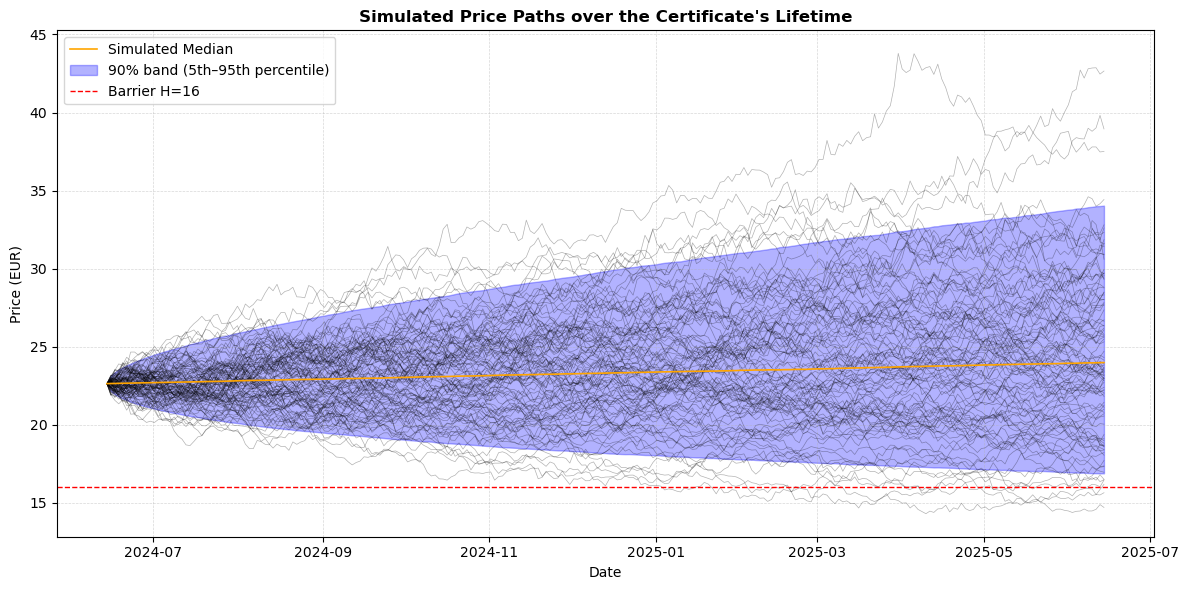

In [13]:
# 90% band (5th to 95th percentile) and median of the simulated price paths
lower_bound = np.percentile(P_paths, 5, axis=0)
median = np.percentile(P_paths, 50, axis=0)
upper_bound = np.percentile(P_paths, 95, axis=0)

start_date = df.index[-1]
sim_dates = pd.date_range(start_date, start_date + pd.Timedelta(days=365), periods=P_paths.shape[1])

plt.figure(figsize=(12, 6))
for i in range(100):
    plt.plot(sim_dates, P_paths[i], color='black', linewidth=0.5, alpha=0.3)
plt.plot(sim_dates, median, color='orange', linewidth=1.2, label='Simulated Median')
plt.fill_between(sim_dates, lower_bound, upper_bound, color='blue', alpha=0.3, label='90% band (5th–95th percentile)')
plt.axhline(H, color='red', linestyle='--', linewidth=1, label=f'Barrier H={H}')
plt.title('Simulated Price Paths over the Certificate\'s Lifetime', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (EUR)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Sensitivity to barrier and volatility

The premium of the certificate over the share is the value of the embedded down-and-out put. It depends strongly on how close the barrier is and on volatility.

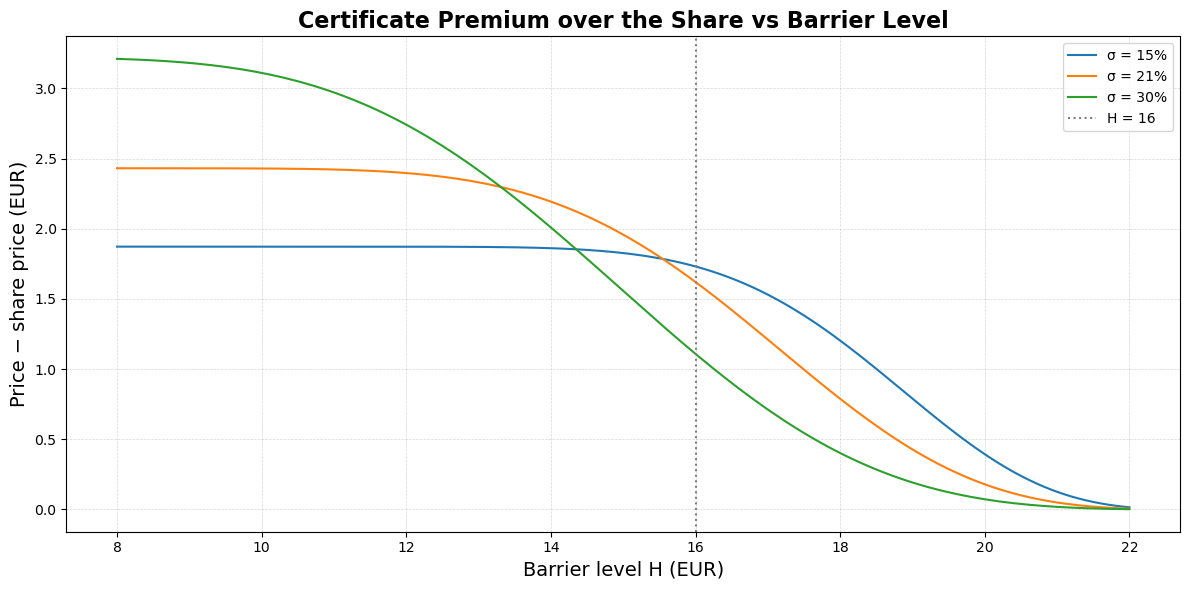

In [14]:
barriers = np.linspace(8, 22, 141)
plt.figure(figsize=(12, 6))
for sig in [0.15, sigma_annual, 0.30]:
    plt.plot(barriers, bonus_certificate_price(P0, B, barriers, r, sig, T) - P0, label=f"σ = {sig:.0%}")
plt.axvline(H, color='grey', linestyle=':', label=f'H = {H}')
plt.title('Certificate Premium over the Share vs Barrier Level', fontsize=16, weight='bold')
plt.xlabel('Barrier level H (EUR)', fontsize=14)
plt.ylabel('Price − share price (EUR)', fontsize=14)
plt.grid(True, linestyle='--', linewidth=.5, alpha=.5)
plt.legend()
plt.tight_layout()
plt.show()

Two effects are visible:

- **Far barrier (low H):** the product behaves like the share plus a vanilla put with strike $B$, so its value **rises** with volatility.
- **Barrier close to the spot (our case, H = 16):** higher volatility makes a knock-out more likely, so the value **falls** with volatility. An investor in the certificate is effectively *short* volatility. This is exactly the barrier risk discussed in Section 3.

## Summary

- Calibrated to ten years of Telekom prices ($\hat\sigma \approx 21\%$), the certificate with $B = 24$ and $H = 16$ is worth about **€24.25**, i.e. €1.62 more than the share.
- Monte Carlo confirms the closed form. Checking the barrier only on a grid overprices the certificate; a Brownian-bridge correction removes this bias.
- Under the real-world measure, the certificate pays exactly the bonus level in about 44% of scenarios and has a higher 5% quantile than the share, but it offers no protection once the barrier is hit.